# Cell 1 — Imports & Environment Info 

In [2]:
# ================================
# Cell 1: Imports & Environment Info
# ================================
import os, sys, math, time, random, json, gc, warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import tifffile
from PIL import Image
from scipy import ndimage as ndi

# torchvision just for simple tensor-level transforms if needed
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

# Progress bars & plotting (optional; can be unused)
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

warnings.filterwarnings("ignore")

# -- Device & perf knobs --
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Env] Torch: {torch.__version__} | CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"[Env] CUDA device count: {torch.cuda.device_count()} | Current device: {torch.cuda.current_device()}")
    print(f"[Env] Device name: {torch.cuda.get_device_name(0)}")

# cuDNN & matmul precision to speed up training
torch.backends.cudnn.benchmark = True
try:
    torch.set_float32_matmul_precision("medium")
except Exception:
    pass

# Small utility: memory snapshot (useful to check dataloader impact later)
def cuda_mem():
    if DEVICE.type != "cuda":
        return "cpu"
    torch.cuda.synchronize()
    return f"alloc={torch.cuda.memory_allocated()/1e9:.2f}GB | reserved={torch.cuda.memory_reserved()/1e9:.2f}GB"

print("[Env] Ready. Device:", DEVICE)
print("[Env] CUDA mem:", cuda_mem())

[Env] Torch: 2.6.0+cu124 | CUDA available: True
[Env] CUDA device count: 1 | Current device: 0
[Env] Device name: NVIDIA RTX 6000 Ada Generation
[Env] Ready. Device: cuda
[Env] CUDA mem: alloc=0.00GB | reserved=0.00GB


# Cell 2 — Data loading (healthy and damaged axons) with contact-gap maps

In [3]:
# ================================
# Cell 2: Load Combined Train/Val + Separate Healthy/Damaged Test Sets
# ================================
DATA_ROOT=Path("path/to/axon_dataset")
HEALTHY_ROOT=DATA_ROOT/"healthy axons";DAMAGED_ROOT=DATA_ROOT/"damaged axons";AXONDEEP_ROOT=DATA_ROOT/"axondeep";NEW_MONTAGE_ROOT=DATA_ROOT/"new montage"
IMG_EXTS={".png",".jpg",".jpeg",".tif",".tiff",".bmp"};NUM_CLASSES=3;CLASS_NAMES=["background","healthy","damaged"]
PATCH_SIZE=512;PATCH_OVERLAP=96;PATCH_STRIDE=PATCH_SIZE-PATCH_OVERLAP;UPSCALE_FACTOR=2.0;CONTACT_GAP_WIDTH=7
NEW_MONTAGE_SCALES=[(2.0,5,"2.0x"),(3.125,7,"3.125x")];IMG_SIZE=PATCH_SIZE

def _list_images(folder):return sorted(p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS)

def _mask_for_image(img_path,label_dir):
    s=img_path.stem;names=[f"{s}_mask{img_path.suffix}",f"{s}.mask{img_path.suffix}",f"{s}_mask.png",f"{s}.mask.png",f"{s}_mask.tif",f"{s}.mask.tif",f"{s}_mask.tiff",f"{s}.mask.tiff",f"{s}.png",f"{s}.tif",f"{s}.tiff"]
    return next((label_dir/n for n in names if (label_dir/n).exists()),None)

def _read_img_rgb_upscale(path,factor):
    with Image.open(path) as im:
        im=im.convert("RGB");w0,h0=im.size;w,h=round(w0*factor),round(h0*factor);x=np.asarray(im.resize((w,h),Image.BILINEAR),np.float32)/255.
    return x.transpose(2,0,1),(h0,w0)

def _read_mask_bin_upscale(path,orig_hw,factor):
    h0,w0=orig_hw;h,w=round(h0*factor),round(w0*factor)
    if path is None:return np.zeros((h,w),bool)
    with Image.open(path) as m:return np.asarray(m.convert("L").resize((w,h),Image.NEAREST),np.uint8)>0

def _make_multiclass_label(healthy,damaged):
    y=np.zeros(healthy.shape,np.int64);y[healthy]=1;y[damaged]=2
    return y

def _contact_gap_map(mask_1hw,gap_width=7):
    mask=mask_1hw[0]>0.5;h,w=mask.shape;n,labels=cv2.connectedComponents(mask.astype(np.uint8),8)
    if n<=2:return np.zeros((1,h,w),np.float32)
    dist,ind=ndi.distance_transform_edt(~mask,return_indices=True);nearest=labels[ind[0],ind[1]];kernel=np.ones((3,3),np.uint8)
    contact=(nearest>0)&(cv2.dilate(nearest.astype(np.float32),kernel)!=cv2.erode(nearest.astype(np.float32),kernel))&(dist>0)&(dist<=gap_width)
    return cv2.dilate(contact.astype(np.uint8),kernel,iterations=1)[None].astype(np.float32)

def _make_contact_map_from_multiclass(label_hw,gap_width=7):return _contact_gap_map((label_hw>0).astype(np.float32)[None],gap_width)

def _extract_patches_multiclass(x,y,c):
    _,h,w=x.shape
    if y.shape!=(h,w):raise ValueError(f"Image/mask mismatch: image={(h,w)}, mask={y.shape}")
    if c.shape!=(1,h,w):raise ValueError(f"Image/contact mismatch: image={(h,w)}, contact={c.shape}")
    if h<PATCH_SIZE or w<PATCH_SIZE:return [],[],[]
    ys=list(range(0,h-PATCH_SIZE+1,PATCH_STRIDE));xs=list(range(0,w-PATCH_SIZE+1,PATCH_STRIDE))
    if ys[-1]!=h-PATCH_SIZE:ys.append(h-PATCH_SIZE)
    if xs[-1]!=w-PATCH_SIZE:xs.append(w-PATCH_SIZE)
    X,Y,C=[],[],[]
    for y0 in ys:
        for x0 in xs:X.append(x[:,y0:y0+PATCH_SIZE,x0:x0+PATCH_SIZE]);Y.append(y[y0:y0+PATCH_SIZE,x0:x0+PATCH_SIZE]);C.append(c[:,y0:y0+PATCH_SIZE,x0:x0+PATCH_SIZE])
    return X,Y,C

########################### For using Full training data (100%) #################################

def _get_dirs(source,split):
    if source=="original":return HEALTHY_ROOT/split/"images",HEALTHY_ROOT/split/"labels",DAMAGED_ROOT/split/"labels"
    root=AXONDEEP_ROOT if source=="axondeep" else NEW_MONTAGE_ROOT
    return root/split/"images",root/split/"labels"/"healthy",root/split/"labels"/"damaged"

# ############################ For using only 10% training data (10%) #################################
# def _get_dirs(source,split):
#     folder="10Percent_train" if split=="train" else split
#     if source=="original":
#         return HEALTHY_ROOT/folder/"images",HEALTHY_ROOT/folder/"labels",DAMAGED_ROOT/folder/"labels"

#     root=AXONDEEP_ROOT if source=="axondeep" else NEW_MONTAGE_ROOT
#     return root/folder/"images",root/folder/"labels"/"healthy",root/folder/"labels"/"damaged"

def _load_source(source,split,scale=2.0,gap=7,make_patches=True,require_both=False):
    img_dir,h_dir,d_dir=_get_dirs(source,split)
    for p in [img_dir,h_dir,d_dir]:
        if not p.is_dir():raise FileNotFoundError(f"Missing folder: {p}")
    X,Y,C,names,shapes,missing=[],[],[],[],[],[]
    for ip in tqdm(_list_images(img_dir),desc=f"{source} {split} {scale:g}x",leave=False):
        hp=_mask_for_image(ip,h_dir);dp=_mask_for_image(ip,d_dir)
        if (require_both and (hp is None or dp is None)) or (hp is None and dp is None):missing.append(ip.name);continue
        x,orig_hw=_read_img_rgb_upscale(ip,scale);healthy=_read_mask_bin_upscale(hp,orig_hw,scale);damaged=_read_mask_bin_upscale(dp,orig_hw,scale);y=_make_multiclass_label(healthy,damaged);c=_make_contact_map_from_multiclass(y,gap)
        if make_patches:xx,yy,cc=_extract_patches_multiclass(x,y,c);X+=xx;Y+=yy;C+=cc
        else:X.append(x);Y.append(y);C.append(c);names.append(ip.stem);shapes.append(orig_hw)
    return X,Y,C,names,shapes,missing

def load_combined_trainval(split):
    X,Y,C,missing=[],[],[],[];counts={}
    a,b,c,_,_,m=_load_source("original",split,UPSCALE_FACTOR,CONTACT_GAP_WIDTH,True,True);X+=a;Y+=b;C+=c;missing+=m;counts["original"]=len(a)
    a,b,c,_,_,m=_load_source("axondeep",split,UPSCALE_FACTOR,CONTACT_GAP_WIDTH,True);X+=a;Y+=b;C+=c;missing+=m;counts["axondeep"]=len(a)
    if split=="train":
        for scale,gap,scale_name in NEW_MONTAGE_SCALES:a,b,c,_,_,m=_load_source("new_montage","train",scale,gap,True);X+=a;Y+=b;C+=c;missing+=m;counts[f"new_montage_{scale_name}"]=len(a)
    X=np.stack(X).astype(np.float32);Y=np.stack(Y).astype(np.int64);C=np.stack(C).astype(np.float32)
    print(f"\n{split}: X={X.shape}, Y={Y.shape}, C={C.shape} | sources={counts}")
    return X,Y,C,missing

def load_binary_test_split(root,split="test",class_name="healthy"):
    img_dir=root/split/"images";label_dir=root/split/"labels";X,Y,names,shapes,missing=[],[],[],[],[]
    for ip in tqdm(_list_images(img_dir),desc=f"Loading {class_name} {split}",leave=False):
        mp=_mask_for_image(ip,label_dir)
        if mp is None:missing.append(ip.name);continue
        x,orig_hw=_read_img_rgb_upscale(ip,UPSCALE_FACTOR);y=_read_mask_bin_upscale(mp,orig_hw,UPSCALE_FACTOR).astype(np.uint8)
        X.append(x);Y.append(y);names.append(ip.stem);shapes.append(orig_hw)
    return X,Y,names,shapes,missing

X_train,Y_train,C_train,miss_tr=load_combined_trainval("train")
X_val,Y_val,C_val,miss_va=load_combined_trainval("val")

X_test_healthy,Y_test_healthy,healthy_test_names,healthy_test_shapes,miss_te_healthy=load_binary_test_split(HEALTHY_ROOT,"test","healthy")
X_test_damaged,Y_test_damaged,damaged_test_names,damaged_test_shapes,miss_te_damaged=load_binary_test_split(DAMAGED_ROOT,"test","damaged")

n=X_train.shape[0]*X_train.shape[2]*X_train.shape[3]
MEAN=(X_train.sum((0,2,3),dtype=np.float64)/n).astype(np.float32)
VAR=np.square(X_train,dtype=np.float64).sum((0,2,3))/n-MEAN.astype(np.float64)**2
STD=np.sqrt(np.maximum(VAR,1e-12)).astype(np.float32)

print(f"\nTrain: X={X_train.shape}, Y={Y_train.shape}, C={C_train.shape}")
print(f"Val:   X={X_val.shape}, Y={Y_val.shape}, C={C_val.shape}")
print(f"Test healthy: {len(X_test_healthy)} | Test damaged: {len(X_test_damaged)}")
print("Train mean:",MEAN.tolist());print("Train std: ",STD.tolist())

for split,y,c in [("train",Y_train,C_train),("val",Y_val,C_val)]:
    counts=np.bincount(y.ravel(),minlength=NUM_CLASSES)
    print(f"{split} pixels:",dict(zip(CLASS_NAMES,counts.tolist())),"| contact:",int(c.sum()))


train: X=(2866, 3, 512, 512), Y=(2866, 512, 512), C=(2866, 1, 512, 512) | sources={'original': 1528, 'axondeep': 650, 'new_montage_2.0x': 200, 'new_montage_3.125x': 488}



val: X=(475, 3, 512, 512), Y=(475, 512, 512), C=(475, 1, 512, 512) | sources={'original': 225, 'axondeep': 250}



Train: X=(2866, 3, 512, 512), Y=(2866, 512, 512), C=(2866, 1, 512, 512)
Val:   X=(475, 3, 512, 512), Y=(475, 512, 512), C=(475, 1, 512, 512)
Test healthy: 18 | Test damaged: 18
Train mean: [0.757270097732544, 0.757270097732544, 0.757270097732544]
Train std:  [0.09223967790603638, 0.09223972260951996, 0.09223981201648712]
train pixels: {'background': 564967704, 'healthy': 146193548, 'damaged': 40143452} | contact: 8907827
val pixels: {'background': 88383132, 'healthy': 30589320, 'damaged': 5545948} | contact: 829941


In [4]:
# ================================
# Cell 2B: Train/Val dataset statistics from ORIGINAL images + GT masks
# ================================
def count_instances(mask):
    return cv2.connectedComponents(mask.astype(np.uint8), connectivity=8)[0]-1

def read_mask_original(path,hw):
    h,w=hw
    if path is None:return np.zeros((h,w),bool)
    with Image.open(path) as m:
        return np.asarray(m.convert("L").resize((w,h),Image.NEAREST),np.uint8)>0

def get_trainval_stats(split):
    rows=[]
    for source in ["original","axondeep","new_montage"]:
        # Current loader uses New Montage only for training
        if source=="new_montage" and split!="train":continue

        img_dir,h_dir,d_dir=_get_dirs(source,split)
        if not img_dir.is_dir():continue

        for ip in tqdm(_list_images(img_dir),desc=f"Stats {source} {split}",leave=False):
            hp=_mask_for_image(ip,h_dir);dp=_mask_for_image(ip,d_dir)

            # Same inclusion rules as training loader
            if source=="original":
                if hp is None or dp is None:continue
            elif hp is None and dp is None:
                continue

            with Image.open(ip) as im:
                w,h=im.size

            healthy=read_mask_original(hp,(h,w))
            damaged=read_mask_original(dp,(h,w))

            rows.append({
                "split":split,"source":source,"image":ip.name,
                "height":h,"width":w,
                "healthy":count_instances(healthy),
                "damaged":count_instances(damaged)
            })

    return pd.DataFrame(rows)

train_stats=get_trainval_stats("train")
val_stats=get_trainval_stats("val")
all_stats=pd.concat([train_stats,val_stats],ignore_index=True)

def report_stats(df,name):
    n_img=len(df)
    h=int(df["healthy"].sum())
    d=int(df["damaged"].sum())
    total=h+d

    min_h,max_h=int(df["height"].min()),int(df["height"].max())
    min_w,max_w=int(df["width"].min()),int(df["width"].max())

    # Overall smallest/largest dimension appearing in any image
    min_dim=int(df[["height","width"]].to_numpy().min())
    max_dim=int(df[["height","width"]].to_numpy().max())

    print(f"\n{name}")
    print("="*55)
    print(f"Images        : {n_img}")
    print(f"Healthy axons : {h:,}")
    print(f"Damaged axons : {d:,}")
    print(f"Total axons   : {total:,}")
    print(f"Height range  : {min_h:,} - {max_h:,} pixels")
    print(f"Width range   : {min_w:,} - {max_w:,} pixels")
    print(f"Overall size range: {min_dim:,} - {max_dim:,} pixels")

report_stats(train_stats,"TRAINING")
report_stats(val_stats,"VALIDATION")
report_stats(all_stats,"TRAINING + VALIDATION")

print("\nBY SOURCE")
print("="*55)
print(
    all_stats.groupby(["split","source"])
    .agg(
        images=("image","count"),
        healthy_axons=("healthy","sum"),
        damaged_axons=("damaged","sum")
    )
)


TRAINING
Images        : 96
Healthy axons : 29,608
Damaged axons : 2,548
Total axons   : 32,156
Height range  : 768 - 1,170 pixels
Width range   : 800 - 1,135 pixels
Overall size range: 768 - 1,170 pixels

VALIDATION
Images        : 19
Healthy axons : 5,490
Damaged axons : 335
Total axons   : 5,825
Height range  : 899 - 1,024 pixels
Width range   : 919 - 1,024 pixels
Overall size range: 899 - 1,024 pixels

TRAINING + VALIDATION
Images        : 115
Healthy axons : 35,098
Damaged axons : 2,883
Total axons   : 37,981
Height range  : 768 - 1,170 pixels
Width range   : 800 - 1,135 pixels
Overall size range: 768 - 1,170 pixels

BY SOURCE
                   images  healthy_axons  damaged_axons
split source                                           
train axondeep         26           7422            156
      new_montage       8           9415             11
      original         62          12771           2381
val   axondeep         10           3307             37
      original         

In [6]:
# ================================
# Cell: Full Test Set Dataset Statistics
# Original + AxonDeep + New Montage
# No model evaluation
# ================================
TEST_SOURCES=["original","axondeep","new_montage"]

def count_gt_instances(mask):
    return cv2.connectedComponents(mask.astype(np.uint8),connectivity=8)[0]-1

def read_mask_original(path,hw):
    h,w=hw
    if path is None:return np.zeros((h,w),bool)
    with Image.open(path) as m:
        return np.asarray(m.convert("L").resize((w,h),Image.NEAREST),np.uint8)>0

def get_test_stats(source):
    img_dir,h_dir,d_dir=_get_dirs(source,"test")
    rows=[]

    for ip in tqdm(_list_images(img_dir),desc=f"Test stats: {source}",leave=False):
        hp=_mask_for_image(ip,h_dir);dp=_mask_for_image(ip,d_dir)

        # Same inclusion rule as Cell 10
        if source=="original":
            if hp is None or dp is None:continue
        elif hp is None and dp is None:
            continue

        with Image.open(ip) as im:
            w,h=im.size

        healthy=read_mask_original(hp,(h,w))
        damaged=read_mask_original(dp,(h,w))

        rows.append({
            "dataset":source,
            "image":ip.name,
            "height":h,
            "width":w,
            "healthy_axons":count_gt_instances(healthy),
            "damaged_axons":count_gt_instances(damaged)
        })

    return pd.DataFrame(rows)

# ---------- Load/count all 3 held-out test sets ----------
test_stats=pd.concat(
    [get_test_stats(source) for source in TEST_SOURCES],
    ignore_index=True
)

test_stats["total_axons"]=test_stats["healthy_axons"]+test_stats["damaged_axons"]

# ---------- Reporting ----------
def report_test_stats(df,name):
    n=len(df)
    healthy=int(df["healthy_axons"].sum())
    damaged=int(df["damaged_axons"].sum())
    total=int(df["total_axons"].sum())

    min_h,max_h=int(df["height"].min()),int(df["height"].max())
    min_w,max_w=int(df["width"].min()),int(df["width"].max())
    min_dim=int(df[["height","width"]].to_numpy().min())
    max_dim=int(df[["height","width"]].to_numpy().max())

    print(f"\n{name}")
    print("="*65)
    print(f"Images             : {n}")
    print(f"Healthy GT axons   : {healthy:,}")
    print(f"Damaged GT axons   : {damaged:,}")
    print(f"Total GT axons     : {total:,}")
    print(f"Height range       : {min_h:,} - {max_h:,} pixels")
    print(f"Width range        : {min_w:,} - {max_w:,} pixels")
    print(f"Overall pixel range: {min_dim:,} - {max_dim:,} pixels")

    return n,healthy,damaged,total,min_h,max_h,min_w,max_w,min_dim,max_dim

# ---------- Each test dataset separately ----------
for source in TEST_SOURCES:
    report_test_stats(
        test_stats[test_stats["dataset"]==source],
        source.upper()
    )

# ---------- All test datasets combined ----------
n,h,d,total,min_h,max_h,min_w,max_w,min_dim,max_dim=report_test_stats(
    test_stats,
    "ALL 3 TEST SETS COMBINED"
)

# ---------- Compact table ----------
test_summary=(
    test_stats.groupby("dataset")
    .agg(
        n_images=("image","size"),
        healthy_GT=("healthy_axons","sum"),
        damaged_GT=("damaged_axons","sum"),
        total_GT=("total_axons","sum"),
        min_height=("height","min"),
        max_height=("height","max"),
        min_width=("width","min"),
        max_width=("width","max")
    )
)

display(test_summary)

# ---------- Manuscript-ready result ----------
print("\nMANUSCRIPT-READY")
print("="*65)
print(
    f"To test performance, we quantitatively evaluated the model on "
    f"independent held-out optic nerve images (n={n}, image dimensions "
    f"ranging from {min_dim:,} to {max_dim:,} pixels, approximately "
    f"{total:,} annotated axons)."
)


ORIGINAL
Images             : 18
Healthy GT axons   : 3,794
Damaged GT axons   : 519
Total GT axons     : 4,313
Height range       : 770 - 900 pixels
Width range        : 750 - 960 pixels
Overall pixel range: 750 - 960 pixels

AXONDEEP
Images             : 18
Healthy GT axons   : 6,230
Damaged GT axons   : 129
Total GT axons     : 6,359
Height range       : 1,024 - 1,024 pixels
Width range        : 1,024 - 1,024 pixels
Overall pixel range: 1,024 - 1,024 pixels

NEW_MONTAGE
Images             : 1
Healthy GT axons   : 715
Damaged GT axons   : 5
Total GT axons     : 720
Height range       : 952 - 952 pixels
Width range        : 1,024 - 1,024 pixels
Overall pixel range: 952 - 1,024 pixels

ALL 3 TEST SETS COMBINED
Images             : 37
Healthy GT axons   : 10,739
Damaged GT axons   : 653
Total GT axons     : 11,392
Height range       : 770 - 1,024 pixels
Width range        : 750 - 1,024 pixels
Overall pixel range: 750 - 1,024 pixels


,n_images,healthy_GT,damaged_GT,total_GT,min_height,max_height,min_width,max_width
dataset,,,,,,,,
axondeep,18,6230,129,6359,1024,1024,1024,1024
new_montage,1,715,5,720,952,952,1024,1024
original,18,3794,519,4313,770,900,750,960



MANUSCRIPT-READY
To test performance, we quantitatively evaluated the model on independent held-out optic nerve images (n=37, image dimensions ranging from 750 to 1,024 pixels, approximately 11,392 annotated axons).


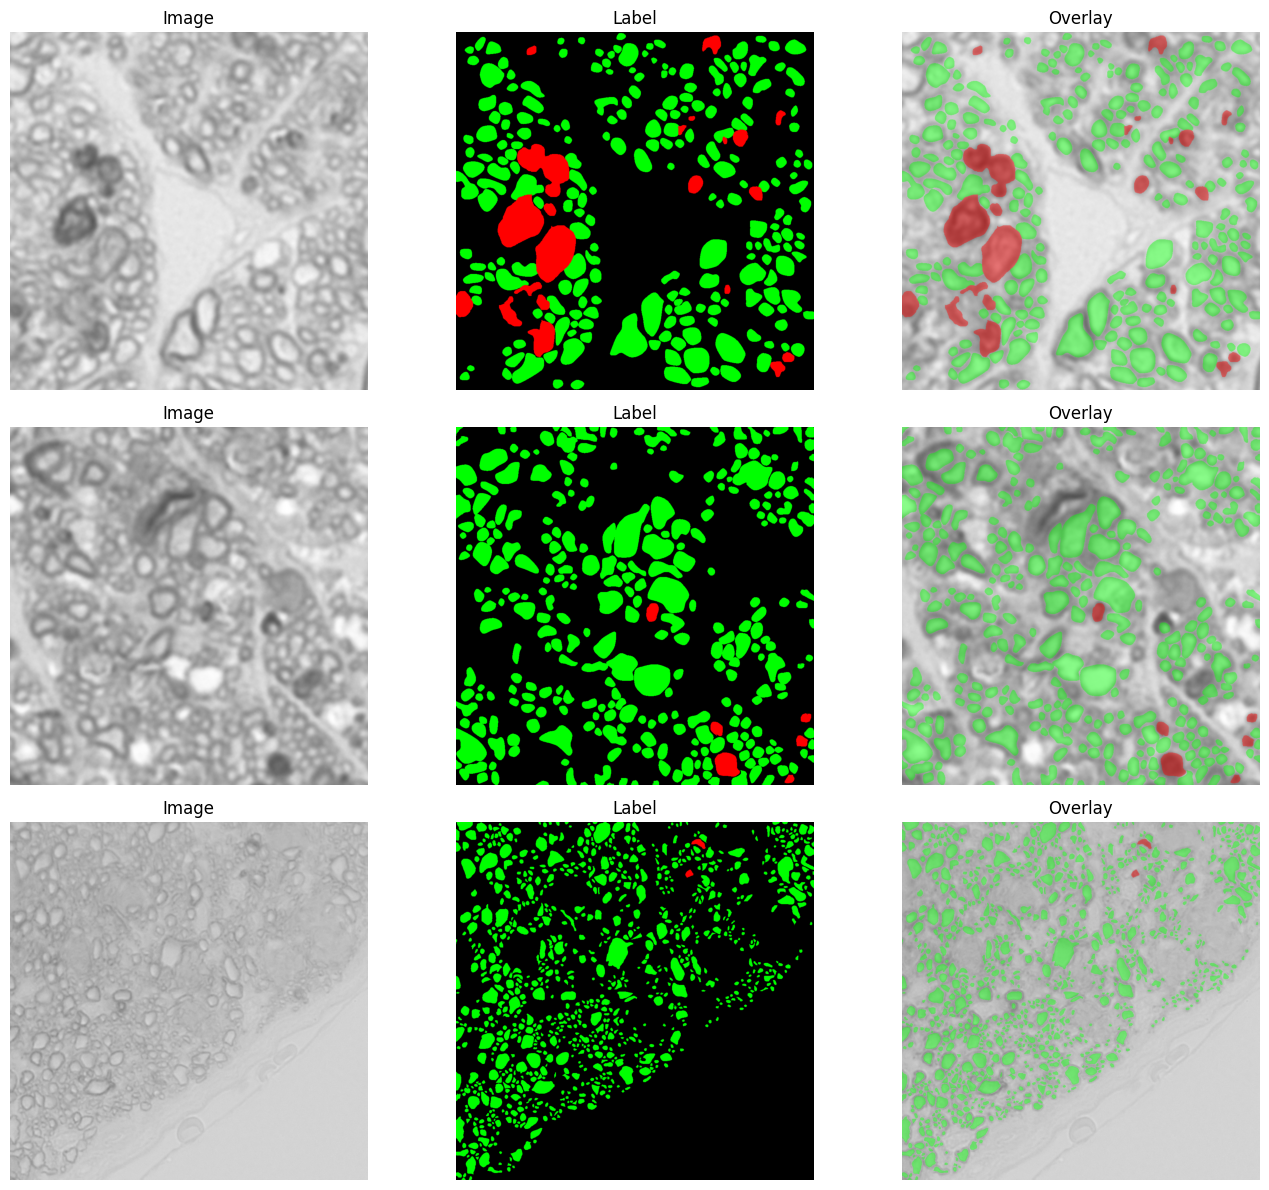

In [4]:
# ================================
# Cell 2.5: Plot training examples from 3 datasets
# ================================
ALPHA=.45
COLORS=np.array([[0,0,0],[0,255,0],[255,0,0]],np.uint8)

sources=[
    ("Original","original",UPSCALE_FACTOR,CONTACT_GAP_WIDTH),
    ("AxonDeep","axondeep",UPSCALE_FACTOR,CONTACT_GAP_WIDTH),
    ("New Montage","new_montage",NEW_MONTAGE_SCALES[0][0],NEW_MONTAGE_SCALES[0][1])
]

fig,axs=plt.subplots(3,3,figsize=(14,12))

for r,(title,source,scale,gap) in enumerate(sources):
    X,Y,_,names,_,_=_load_source(source,"train",scale,gap,make_patches=False,require_both=source=="original")
    i=0

    img=np.clip(X[i].transpose(1,2,0),0,1)
    y=Y[i]
    color=COLORS[y]/255.

    overlay=img.copy()
    m=y>0
    overlay[m]=(1-ALPHA)*img[m]+ALPHA*color[m]

    axs[r,0].imshow(img)
    axs[r,1].imshow(color)
    axs[r,2].imshow(overlay)

    axs[r,0].set_ylabel(f"{title}\n{names[i]}",fontsize=11)

    for c,t in enumerate(["Image","Label","Overlay"]):
        axs[r,c].set_title(t)
        axs[r,c].axis("off")

plt.tight_layout()
plt.show()

# Cell 3 — Config & Seeds

In [4]:
## ================================
# Cell 3: Config & Seeds
# ================================
SEED=42

def seed_everything(seed=SEED):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    if torch.cuda.is_available():torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

BASE_DIR=Path("./micro_sam_lora")
CKPT_DIR=BASE_DIR/"checkpoints";LOGS_DIR=BASE_DIR/"logs";OVERLAY_DIR=BASE_DIR/"overlays";RESULTS_DIR=BASE_DIR/"results";MODELS_DIR=BASE_DIR/"models"
for d in [BASE_DIR,CKPT_DIR,LOGS_DIR,OVERLAY_DIR,RESULTS_DIR,MODELS_DIR]:d.mkdir(parents=True,exist_ok=True)

NUM_CLASSES=3;CLASS_NAMES=["background","healthy","damaged"]
BACKGROUND_ID=0;HEALTHY_ID=1;DAMAGED_ID=2

N_AUG_VIEWS=8;BATCH_SIZE=32;NUM_WORKERS=0;PIN_MEMORY=torch.cuda.is_available()
EPOCHS=80;PATIENCE=10;GRAD_CLIP=1.;BASE_LR=3e-4

CE_LOSS_W=.5;DICE_LOSS_W=.5;CONTACT_ALPHA=2.

SAM_MEAN=[.485,.456,.406];SAM_STD=[.229,.224,.225]
SAM_MEAN_T=torch.tensor(SAM_MEAN,dtype=torch.float32).view(1,3,1,1)
SAM_STD_T=torch.tensor(SAM_STD,dtype=torch.float32).view(1,3,1,1)

def sam_normalize(x):
    single=x.ndim==3
    if single:x=x.unsqueeze(0)
    if x.ndim!=4:raise ValueError(f"sam_normalize expects 3D/4D tensor, got {tuple(x.shape)}")
    x=(x-SAM_MEAN_T.to(x.device))/SAM_STD_T.to(x.device)
    return x.squeeze(0) if single else x

print("[Paths]",BASE_DIR)
print(f"[Config] IMG_SIZE={IMG_SIZE} | BATCH_SIZE={BATCH_SIZE} | EPOCHS={EPOCHS} | LR={BASE_LR} | GRAD_CLIP={GRAD_CLIP}")
print("[Classes]",{i:name for i,name in enumerate(CLASS_NAMES)})
print(f"[Loss] CE={CE_LOSS_W} | Dice={DICE_LOSS_W} | CONTACT_ALPHA={CONTACT_ALPHA}")
print("[Norm] mean:",SAM_MEAN,"| std:",SAM_STD)

[Paths] C:\Users\Dhruba\Codes\micro_sam_lora
[Config] IMG_SIZE=512 | BATCH_SIZE=32 | EPOCHS=100 | LR=0.0003 | GRAD_CLIP=1.0
[Classes] {0: 'background', 1: 'healthy', 2: 'damaged'}
[Loss] CE=0.5 | Dice=0.5 | CONTACT_ALPHA=2.0
[Norm] mean: [0.485, 0.456, 0.406] | std: [0.229, 0.224, 0.225]


# Cell 4 — Offline augmentation and normalization + creates DataLoaders

In [5]:
# ================================
# Cell 4: Offline augmentation + normalization + DataLoaders
# ================================
from torch.utils.data import Dataset,DataLoader

def assert_ready_multiclass(X,Y,C,name):
    assert isinstance(X,np.ndarray) and isinstance(Y,np.ndarray) and isinstance(C,np.ndarray)
    assert X.ndim==4 and X.shape[1]==3 and Y.ndim==3 and C.ndim==4 and C.shape[1]==1
    assert X.shape[0]==Y.shape[0]==C.shape[0] and X.shape[2:]==Y.shape[1:]==C.shape[2:]
    assert X.dtype==np.float32 and np.issubdtype(Y.dtype,np.integer) and C.dtype==np.float32
    vals=np.unique(Y);bad=[int(v) for v in vals if int(v) not in range(NUM_CLASSES)]
    if bad:raise ValueError(f"{name}: invalid classes {bad}")
    cvals=np.unique(C)
    if not np.all(np.isin(cvals,[0.,1.])):raise ValueError(f"{name}: invalid contact values {cvals[:10]}")
    print(f"[Check {name}] X={X.shape}, Y={Y.shape}, C={C.shape}, classes={vals.tolist()}, contact={int(C.sum()):,}")

def assert_ready_binary_list(X,Y,name):
    assert isinstance(X,list) and isinstance(Y,list) and len(X)==len(Y)
    for i,(x,y) in enumerate(zip(X,Y)):
        assert isinstance(x,np.ndarray) and isinstance(y,np.ndarray)
        assert x.ndim==3 and x.shape[0]==3 and y.ndim==2 and x.shape[1:]==y.shape
        assert x.dtype==np.float32 and (np.issubdtype(y.dtype,np.integer) or y.dtype==bool)
        vals=np.unique(y);bad=[int(v) for v in vals if int(v) not in [0,1]]
        if bad:raise ValueError(f"{name} #{i}: invalid values {bad}")
    print(f"[Check {name}] N={len(X)} full-size images")

assert_ready_multiclass(X_train,Y_train,C_train,"train")
assert_ready_multiclass(X_val,Y_val,C_val,"val")
assert_ready_binary_list(X_test_healthy,Y_test_healthy,"healthy test")
assert_ready_binary_list(X_test_damaged,Y_test_damaged,"damaged test")

def _apply_offline_aug_multiclass(img,lab,contact,g):
    if torch.rand((),generator=g).item()<.5:img=torch.flip(img,(2,));lab=torch.flip(lab,(1,));contact=torch.flip(contact,(2,))
    if torch.rand((),generator=g).item()<.5:img=torch.flip(img,(1,));lab=torch.flip(lab,(0,));contact=torch.flip(contact,(1,))
    k=int(torch.randint(0,4,(),generator=g).item())
    if k:img=torch.rot90(img,k,(1,2));lab=torch.rot90(lab,k,(0,1));contact=torch.rot90(contact,k,(1,2))
    if torch.rand((),generator=g).item()<.5:img=(img+(torch.rand((),generator=g).item()*.30-.15)).clamp(0,1)
    if torch.rand((),generator=g).item()<.5:
        contrast=1.+(torch.rand((),generator=g).item()*.60-.30);mean=img.mean((1,2),keepdim=True);img=((img-mean)*contrast+mean).clamp(0,1)
    if torch.rand((),generator=g).item()<.35:img=torch.clamp(img,0,1)**(1.+torch.rand((),generator=g).item()*.8)
    return img,lab,contact

@torch.no_grad()
def make_offline_train_tensors_multiclass(X_np,Y_np,C_np,n_views,seed=42,do_aug=True,normalize_fn=None):
    X=torch.from_numpy(X_np).float();Y=torch.from_numpy(Y_np).long();C=torch.from_numpy(C_np).float()
    N,_,H,W=X.shape;V=max(1,int(n_views)) if do_aug else 1
    Xo=torch.empty((N*V,3,H,W),dtype=torch.float32);Yo=torch.empty((N*V,H,W),dtype=torch.long);Co=torch.empty((N*V,1,H,W),dtype=torch.float32)
    g=torch.Generator(device="cpu");g.manual_seed(seed);j=0

    for i in tqdm(range(N),desc=f"Offline augmentation ({V} views)",unit="patch"):
        for _ in range(V):
            img,lab,contact=X[i],Y[i],C[i]
            if do_aug:img,lab,contact=_apply_offline_aug_multiclass(img,lab,contact,g)
            if normalize_fn is not None:img=normalize_fn(img)
            Xo[j]=img;Yo[j]=lab;Co[j]=contact;j+=1

    return Xo.contiguous(),Yo.contiguous(),Co.contiguous()

@torch.no_grad()
def make_offline_eval_tensors_multiclass(X_np,Y_np,C_np,normalize_fn=None):
    X=torch.from_numpy(X_np).float();Y=torch.from_numpy(Y_np).long();C=torch.from_numpy(C_np).float()
    if normalize_fn is not None:X=normalize_fn(X)
    return X.contiguous(),Y.contiguous(),C.contiguous()

Xtr_t,Ytr_t,Ctr_t=make_offline_train_tensors_multiclass(X_train,Y_train,C_train,N_AUG_VIEWS,SEED,True,sam_normalize)
Xva_t,Yva_t,Cva_t=make_offline_eval_tensors_multiclass(X_val,Y_val,C_val,sam_normalize)

print("\n[Offline tensors]")
print("Train:",Xtr_t.shape,Ytr_t.shape,Ctr_t.shape)
print("Val:  ",Xva_t.shape,Yva_t.shape,Cva_t.shape)
print("Test healthy:",len(X_test_healthy),"full-size images")
print("Test damaged:",len(X_test_damaged),"full-size images")

class TensorSegDataset(Dataset):
    def __init__(self,X,Y,C):self.X,self.Y,self.C=X,Y,C
    def __len__(self):return len(self.X)
    def __getitem__(self,i):return self.X[i],self.Y[i],self.C[i]

train_ds=TensorSegDataset(Xtr_t,Ytr_t,Ctr_t)
val_ds=TensorSegDataset(Xva_t,Yva_t,Cva_t)

train_dl=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS,pin_memory=PIN_MEMORY)
val_dl=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=PIN_MEMORY)

print(f"\n[DL] Train samples: {len(train_ds):,} | steps/epoch: {len(train_dl):,}")
print(f"[DL] Val samples:   {len(val_ds):,} | steps/epoch: {len(val_dl):,}")
print("[Env] CUDA mem:",cuda_mem())

[Check train] X=(189, 3, 512, 512), Y=(189, 512, 512), C=(189, 1, 512, 512), classes=[0, 1, 2], contact=435,672
[Check val] X=(475, 3, 512, 512), Y=(475, 512, 512), C=(475, 1, 512, 512), classes=[0, 1, 2], contact=829,941
[Check healthy test] N=18 full-size images
[Check damaged test] N=18 full-size images


Offline augmentation (8 views): 100%|█████████████████████████████████████████████| 189/189 [00:04<00:00, 38.86patch/s]



[Offline tensors]
Train: torch.Size([1512, 3, 512, 512]) torch.Size([1512, 512, 512]) torch.Size([1512, 1, 512, 512])
Val:   torch.Size([475, 3, 512, 512]) torch.Size([475, 512, 512]) torch.Size([475, 1, 512, 512])
Test healthy: 18 full-size images
Test damaged: 18 full-size images

[DL] Train samples: 1,512 | steps/epoch: 48
[DL] Val samples:   475 | steps/epoch: 15
[Env] CUDA mem: alloc=0.00GB | reserved=0.00GB


# Cell 5 — Build µSAM + attach LoRA (last N blocks) + AIS decoder skeleton

In [6]:
# ================================
# Cell 5: µSAM vit_b_lm + LoRA + multiclass AIS decoder
# ================================
from segment_anything import sam_model_registry

MODEL_TYPE="vit_b";ENC_OUT_CH=256;USAM_LM_CKPT=MODELS_DIR/"vit_b_lm.pt"
print(f"[Cfg] {MODEL_TYPE} | ENC_OUT_CH={ENC_OUT_CH} | classes={NUM_CLASSES}")

sam=sam_model_registry[MODEL_TYPE](checkpoint=None)
print(f"[SAM] {len(sam.image_encoder.blocks)} encoder blocks")

# ---------- Load µSAM weights ----------
if not USAM_LM_CKPT.is_file():
    raise FileNotFoundError(f"µSAM checkpoint not found: {USAM_LM_CKPT}")

raw=torch.load(USAM_LM_CKPT,map_location="cpu")
state=raw.get("model",raw.get("state_dict",raw)) if isinstance(raw,dict) else raw

try:
    ms,us=sam.load_state_dict(state,strict=False)
    print(f"[Load] Full SAM: missing={len(ms)} | unexpected={len(us)}")
except Exception as e:
    print(f"[Load] Full load failed: {type(e).__name__}: {e}")

enc_keys=set(sam.image_encoder.state_dict().keys())
if any(k.startswith("image_encoder.") for k in state):
    enc_sd={k.replace("image_encoder.","",1):v for k,v in state.items() if k.startswith("image_encoder.")}
else:
    enc_sd={k:v for k,v in state.items() if k in enc_keys}

r=sam.image_encoder.load_state_dict(enc_sd,strict=False)
print(f"[Load] Encoder: missing={len(r.missing_keys)} | unexpected={len(r.unexpected_keys)}")

# ---------- LoRA ----------
class LoRAWrappedLinear(nn.Module):
    def __init__(self,base_linear,r=8,alpha=8,dropout=.1):
        super().__init__();self.base=base_linear
        for p in self.base.parameters():p.requires_grad=False
        in_f,out_f=self.base.in_features,self.base.out_features
        self.r=int(r);self.scale=float(alpha)/max(self.r,1);self.drop=nn.Dropout(dropout) if dropout>0 else nn.Identity()
        if self.r>0:
            self.lora_A=nn.Linear(in_f,self.r,bias=False);self.lora_B=nn.Linear(self.r,out_f,bias=False)
            nn.init.kaiming_uniform_(self.lora_A.weight,a=math.sqrt(5));nn.init.zeros_(self.lora_B.weight)

    def forward(self,x):
        y=self.base(x)
        if self.r>0:y=y+self.drop(self.lora_B(self.lora_A(x)))*self.scale
        return y

def _try_wrap_attr(parent,name,**kw):
    if parent is None or not hasattr(parent,name):return False
    m=getattr(parent,name)
    if isinstance(m,nn.Linear) and not isinstance(m,LoRAWrappedLinear):
        setattr(parent,name,LoRAWrappedLinear(m,**kw));return True
    return False

def attach_lora_lastN_blocks(sam_model,last_n=4,r=8,alpha=8,dropout=.1,wrap_attn=True,wrap_mlp=True):
    blocks=sam_model.image_encoder.blocks;start=max(0,len(blocks)-int(last_n));cnt_attn=cnt_mlp=0
    for blk in blocks[start:]:
        if wrap_attn:
            for nm in ("qkv","proj","out_proj","o_proj"):
                if _try_wrap_attr(getattr(blk,"attn",None),nm,r=r,alpha=alpha,dropout=dropout):cnt_attn+=1
        if wrap_mlp:
            mlp=getattr(blk,"mlp",None)
            for nm in ("fc1","fc2","linear1","linear2","lin1","lin2","w1","w2"):
                if _try_wrap_attr(mlp,nm,r=r,alpha=alpha,dropout=dropout):cnt_mlp+=1
            if mlp is not None:
                for cname,child in list(mlp.named_children()):
                    if isinstance(child,nn.Linear) and not isinstance(child,LoRAWrappedLinear):
                        setattr(mlp,cname,LoRAWrappedLinear(child,r=r,alpha=alpha,dropout=dropout));cnt_mlp+=1
    print(f"[LoRA] last {last_n} blocks | attn={cnt_attn} | mlp={cnt_mlp}")

LAST_N_BLOCKS=4;LORA_R=8;LORA_ALPHA=8;LORA_DROPOUT=.10
attach_lora_lastN_blocks(sam,LAST_N_BLOCKS,LORA_R,LORA_ALPHA,LORA_DROPOUT)

for p in sam.parameters():p.requires_grad=False
lora_cnt=0
for m in sam.modules():
    if isinstance(m,LoRAWrappedLinear) and m.r>0:
        for p in m.lora_A.parameters():p.requires_grad=True
        for p in m.lora_B.parameters():p.requires_grad=True
        lora_cnt+=1
print(f"[Freeze] LoRA enabled on {lora_cnt} Linear modules; base SAM frozen")

# ---------- Multiclass AIS decoder ----------
class AISDecoder(nn.Module):
    def __init__(self,in_ch=ENC_OUT_CH,mid_ch=128,num_classes=NUM_CLASSES):
        super().__init__()
        self.stem=nn.Sequential(nn.Conv2d(in_ch,mid_ch,3,padding=1,bias=False),nn.InstanceNorm2d(mid_ch,affine=True),nn.GELU())
        self.refine=nn.Sequential(
            nn.Conv2d(mid_ch,mid_ch//2,3,padding=1,bias=False),nn.InstanceNorm2d(mid_ch//2,affine=True),nn.GELU(),
            nn.Conv2d(mid_ch//2,mid_ch//4,3,padding=1,bias=False),nn.InstanceNorm2d(mid_ch//4,affine=True),nn.GELU())
        self.head=nn.Conv2d(mid_ch//4,num_classes,1)

    def forward(self,feat):
        x=self.stem(feat);x=F.interpolate(x,size=(IMG_SIZE,IMG_SIZE),mode="bilinear",align_corners=False)
        return self.head(self.refine(x))

ais_decoder=AISDecoder(ENC_OUT_CH,128,NUM_CLASSES)
sam=sam.to(DEVICE);ais_decoder=ais_decoder.to(DEVICE)

def _count_trainable(m):return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"[Params] SAM total:      {sum(p.numel() for p in sam.parameters()):,}")
print(f"[Params] LoRA trainable: {_count_trainable(sam):,}")
print(f"[Params] AIS trainable:  {_count_trainable(ais_decoder):,}")
print("[Env] CUDA mem:",cuda_mem())

[Cfg] vit_b | ENC_OUT_CH=256 | classes=3
[SAM] 12 encoder blocks
[Load] Full SAM: missing=0 | unexpected=0
[Load] Encoder: missing=0 | unexpected=0
[LoRA] last 4 blocks | attn=8 | mlp=8
[Freeze] LoRA enabled on 16 Linear modules; base SAM frozen
[Params] SAM total:      94,128,688
[Params] LoRA trainable: 393,216
[Params] AIS trainable:  387,619
[Env] CUDA mem: alloc=0.38GB | reserved=0.42GB


# Cell 5.5 -- adapt SAM to IMG_SIZE 512x512

In [7]:
# ================================
# Cell 5.5: Adapt SAM pos_embed to IMG_SIZE
# ================================

@torch.no_grad()
def resize_sam_pos_embed(sam_model, img_size: int):
    enc = sam_model.image_encoder

    # SAM uses patch size 16
    patch = enc.patch_embed.proj.kernel_size[0]
    new_grid = img_size // patch

    pe = enc.pos_embed  # [1, Gh, Gw, C]

    if pe is None:
        print("[pos_embed] None -> nothing to resize.")
        return

    old_grid = pe.shape[1]

    if old_grid == new_grid:
        print(f"[pos_embed] Already matches grid {new_grid}x{new_grid}.")
        return

    pe_ = pe.permute(0, 3, 1, 2).contiguous()
    pe_ = F.interpolate(
        pe_,
        size=(new_grid, new_grid),
        mode="bilinear",
        align_corners=False
    )
    pe_ = pe_.permute(0, 2, 3, 1).contiguous()

    enc.pos_embed = nn.Parameter(pe_)
    enc.img_size = img_size

    print(f"[pos_embed] Resized {old_grid}x{old_grid} -> {new_grid}x{new_grid} (IMG_SIZE={img_size})")

resize_sam_pos_embed(sam, IMG_SIZE)
print("pos_embed shape:", tuple(sam.image_encoder.pos_embed.shape))

[pos_embed] Resized 64x64 -> 32x32 (IMG_SIZE=512)
pos_embed shape: (1, 32, 32, 768)


# Cell 6 — Losses, optimizer (train LoRA + AIS only)

In [8]:
# ================================
# Cell 6: Forward + multiclass loss/metrics + optimizer
# ================================
def forward_logits(x):
    return ais_decoder(sam.image_encoder(x))

def multiclass_dice_from_logits(logits,target,num_classes=NUM_CLASSES,include_background=False,eps=1e-7):
    probs=torch.softmax(logits,1)
    target_oh=F.one_hot(target.long(),num_classes).permute(0,3,1,2).float()
    inter=(probs*target_oh).sum((0,2,3));den=probs.sum((0,2,3))+target_oh.sum((0,2,3))
    dice=(2*inter+eps)/(den+eps)
    return (dice.mean() if include_background else dice[1:].mean()),dice

def multiclass_dice_loss_from_logits(logits,target,num_classes=NUM_CLASSES,include_background=False,eps=1e-7):
    mean_dice,_=multiclass_dice_from_logits(logits,target,num_classes,include_background,eps)
    return 1-mean_dice

def hard_dice_per_class_from_logits(logits,target,num_classes=NUM_CLASSES,eps=1e-7):
    pred=logits.argmax(1);dices=[]
    for cls in range(num_classes):
        p,g=pred==cls,target==cls;inter=(p&g).sum();den=p.sum()+g.sum()
        dices.append((2*inter+eps)/(den+eps))
    dices=torch.stack(dices)
    return dices[1:].mean(),dices

def segmentation_loss(logits,targets,contact):
    ce=F.cross_entropy(logits,targets.long(),reduction="none")
    weights=1.+CONTACT_ALPHA*contact[:,0].float()
    ce=(ce*weights).sum()/weights.sum().clamp_min(1e-7)
    dice_l=multiclass_dice_loss_from_logits(logits,targets)
    total=CE_LOSS_W*ce+DICE_LOSS_W*dice_l
    return {"total":total,"ce":ce.detach(),"dice_loss":dice_l.detach()}

# ---------- Optimizer ----------
lora_params=[p for p in sam.parameters() if p.requires_grad]
ais_params=[p for p in ais_decoder.parameters() if p.requires_grad]
assert lora_params,"No LoRA parameters found."
assert ais_params,"No AIS parameters found."

optim=torch.optim.AdamW([
    {"params":lora_params,"lr":BASE_LR*.5,"weight_decay":.01},
    {"params":ais_params,"lr":BASE_LR,"weight_decay":.01}
])

USE_AMP=DEVICE.type=="cuda"
scaler=torch.amp.GradScaler("cuda",enabled=USE_AMP)

print("[Optim] AdamW configured")
print(f"LoRA: {sum(p.numel() for p in lora_params):,} params | LR={BASE_LR*.5:g}")
print(f"AIS:  {sum(p.numel() for p in ais_params):,} params | LR={BASE_LR:g}")
print(f"[AMP] enabled={USE_AMP}")
print("[Env] CUDA mem:",cuda_mem())

[Optim] AdamW configured
LoRA: 1,179,648 params | LR=0.00015
AIS:  387,619 params | LR=0.0003
[AMP] enabled=True
[Env] CUDA mem: alloc=0.37GB | reserved=0.44GB


# Cell 7 — Train/Eval loops, early stop, and checkpointing

In [9]:
# ================================
# Cell 7: Training loop + checkpointing
# ================================
RUN_TAG=f"microSAM_LoRA_AxonSeg_img{IMG_SIZE}"
RUN_CKPT_DIR=CKPT_DIR/RUN_TAG;RUN_CKPT_DIR.mkdir(parents=True,exist_ok=True)
BEST_DICE_CKPT_PATH=RUN_CKPT_DIR/"best_dice.pt";BEST_LOSS_CKPT_PATH=RUN_CKPT_DIR/"best_loss.pt"
LAST_CKPT_PATH=RUN_CKPT_DIR/"last.pt";HIST_JSON_PATH=RUN_CKPT_DIR/"history.json"

def save_checkpoint(path,epoch,monitor_name,monitor_value,history,sam,ais_decoder,optim,scaler):
    torch.save({"epoch":int(epoch),"monitor_name":monitor_name,"monitor_value":float(monitor_value),"history":history,
                "sam_state":sam.state_dict(),"ais_state":ais_decoder.state_dict(),"optim_state":optim.state_dict(),
                "scaler_state":scaler.state_dict() if scaler is not None else None,"num_classes":NUM_CLASSES,
                "class_names":CLASS_NAMES,"img_size":IMG_SIZE},path)

def save_history_json(history):
    with open(HIST_JSON_PATH,"w") as f:json.dump(history,f,indent=2)

def run_one_epoch_train(epoch,sam,ais_decoder,train_dl,optim,scaler,grad_clip=GRAD_CLIP):
    sam.train();ais_decoder.train()
    loss_sum=dice_sum=h_sum=d_sum=0.;n_batches=0
    pbar=tqdm(train_dl,desc=f"ep{epoch:02d} train",leave=False)

    for x,y,contact in pbar:
        x=x.to(DEVICE,non_blocking=True);y=y.to(DEVICE,non_blocking=True).long();contact=contact.to(DEVICE,non_blocking=True).float()
        optim.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda",enabled=USE_AMP):
            logits=forward_logits(x);losses=segmentation_loss(logits,y,contact);loss=losses["total"]

        scaler.scale(loss).backward()

        if grad_clip:
            scaler.unscale_(optim)
            params=[p for p in sam.parameters() if p.requires_grad]+[p for p in ais_decoder.parameters() if p.requires_grad]
            torch.nn.utils.clip_grad_norm_(params,grad_clip)

        scaler.step(optim);scaler.update()

        with torch.no_grad():mean_dice,dices=hard_dice_per_class_from_logits(logits.detach(),y.detach(),NUM_CLASSES)

        loss_sum+=loss.item();dice_sum+=mean_dice.item();h_sum+=dices[HEALTHY_ID].item();d_sum+=dices[DAMAGED_ID].item();n_batches+=1
        pbar.set_postfix(loss=f"{loss.item():.4f}",dice=f"{mean_dice.item():.3f}",H=f"{dices[HEALTHY_ID].item():.3f}",D=f"{dices[DAMAGED_ID].item():.3f}")

    return {"loss":loss_sum/n_batches,"dice":dice_sum/n_batches,"dice_healthy":h_sum/n_batches,"dice_damaged":d_sum/n_batches}

@torch.no_grad()
def run_one_epoch_val(epoch,sam,ais_decoder,val_dl):
    sam.eval();ais_decoder.eval()
    loss_sum=dice_sum=h_sum=d_sum=0.;n_batches=0

    for x,y,contact in tqdm(val_dl,desc=f"ep{epoch:02d} val",leave=False):
        x=x.to(DEVICE,non_blocking=True);y=y.to(DEVICE,non_blocking=True).long();contact=contact.to(DEVICE,non_blocking=True).float()

        with torch.amp.autocast("cuda",enabled=USE_AMP):
            logits=forward_logits(x);loss=segmentation_loss(logits,y,contact)["total"]

        mean_dice,dices=hard_dice_per_class_from_logits(logits,y,NUM_CLASSES)
        loss_sum+=loss.item();dice_sum+=mean_dice.item();h_sum+=dices[HEALTHY_ID].item();d_sum+=dices[DAMAGED_ID].item();n_batches+=1

    return {"loss":loss_sum/n_batches,"dice":dice_sum/n_batches,"dice_healthy":h_sum/n_batches,"dice_damaged":d_sum/n_batches}

def train_model(sam,ais_decoder,train_dl,val_dl,optim,scaler,epochs=EPOCHS,patience=PATIENCE):
    history={"train_loss":[],"val_loss":[],"train_dice":[],"val_dice":[],
             "train_dice_healthy":[],"val_dice_healthy":[],"train_dice_damaged":[],"val_dice_damaged":[],
             "best_dice_epoch":None,"best_dice":None,"best_loss_epoch":None,"best_loss":None}

    best_dice=-np.inf;best_loss=np.inf;best_dice_epoch=best_loss_epoch=0;bad_epochs=0

    for ep in range(1,epochs+1):
        t0=time.time()
        tr=run_one_epoch_train(ep,sam,ais_decoder,train_dl,optim,scaler)
        va=run_one_epoch_val(ep,sam,ais_decoder,val_dl)

        val_dice=va["dice"];val_loss=va["loss"]
        history["train_loss"].append(tr["loss"]);history["val_loss"].append(val_loss)
        history["train_dice"].append(tr["dice"]);history["val_dice"].append(val_dice)
        history["train_dice_healthy"].append(tr["dice_healthy"]);history["val_dice_healthy"].append(va["dice_healthy"])
        history["train_dice_damaged"].append(tr["dice_damaged"]);history["val_dice_damaged"].append(va["dice_damaged"])

        improved_dice=val_dice>best_dice;improved_loss=val_loss<best_loss

        if improved_dice:
            best_dice=val_dice;best_dice_epoch=ep;bad_epochs=0
            history["best_dice_epoch"]=ep;history["best_dice"]=float(best_dice)
            save_checkpoint(BEST_DICE_CKPT_PATH,ep,"val_dice",best_dice,history,sam,ais_decoder,optim,scaler)
        else:bad_epochs+=1

        if improved_loss:
            best_loss=val_loss;best_loss_epoch=ep
            history["best_loss_epoch"]=ep;history["best_loss"]=float(best_loss)
            save_checkpoint(BEST_LOSS_CKPT_PATH,ep,"val_loss",best_loss,history,sam,ais_decoder,optim,scaler)

        save_checkpoint(LAST_CKPT_PATH,ep,"last",val_dice,history,sam,ais_decoder,optim,scaler);save_history_json(history)

        print(f"Epoch {ep:03d} | train {tr['loss']:.4f} | val {val_loss:.4f} | Dice {val_dice:.4f} | "
              f"H {va['dice_healthy']:.4f} | D {va['dice_damaged']:.4f} | "
              f"best Dice {best_dice:.4f}@{best_dice_epoch} | best loss {best_loss:.4f}@{best_loss_epoch} | "
              f"patience {bad_epochs}/{patience} | {time.time()-t0:.1f}s")

        if bad_epochs>=patience:
            print("Early stopping triggered")
            break

    print(f"\nBest Dice: epoch {best_dice_epoch} | {best_dice:.4f}")
    print(f"Best Loss: epoch {best_loss_epoch} | {best_loss:.4f}")
    return history

In [9]:
with torch.no_grad():

    x, y, contact = next(iter(train_dl))

    x = x.to(DEVICE)

    seg_logits = forward_logits(x)

print("seg_logits :", seg_logits.shape)
print("mask_gt    :", y.shape)

print("\nunique GT classes:", torch.unique(y))

pred = torch.argmax(seg_logits, dim=1)

print("pred shape :", pred.shape)
print("unique pred classes:", torch.unique(pred))
print("contact map:", contact.shape)
print("contact pixels:", int(contact.sum()))

seg_logits : torch.Size([32, 3, 512, 512])
mask_gt    : torch.Size([32, 512, 512])

unique GT classes: tensor([0, 1, 2])
pred shape : torch.Size([32, 512, 512])
unique pred classes: tensor([0, 1, 2], device='cuda:0')
contact map: torch.Size([32, 1, 512, 512])
contact pixels: 90479


# Cell 8 — RUN training

In [10]:
# ================================
# Cell 8: Run training
# ================================
import gc

EPOCHS=80
PATIENCE=10

gc.collect()
if DEVICE.type=="cuda":torch.cuda.empty_cache()
print("[Env] CUDA mem:",cuda_mem())

history=train_model(sam,ais_decoder,train_dl,val_dl,optim,scaler,epochs=EPOCHS,patience=PATIENCE)

best_dice_ep=history.get("best_dice_epoch")
best_dice=history.get("best_dice")
if best_dice_ep is not None:
    i=best_dice_ep-1
    print("\n[Summary: Best Dice Checkpoint]")
    print(f"Epoch={best_dice_ep} | Val Dice={best_dice:.4f} | Val Loss={history['val_loss'][i]:.4f} | "
          f"H={history['val_dice_healthy'][i]:.4f} | D={history['val_dice_damaged'][i]:.4f}")

best_loss_ep=history.get("best_loss_epoch")
best_loss=history.get("best_loss")
if best_loss_ep is not None:
    i=best_loss_ep-1
    print("\n[Summary: Best Loss Checkpoint]")
    print(f"Epoch={best_loss_ep} | Val Loss={best_loss:.4f} | Val Dice={history['val_dice'][i]:.4f} | "
          f"H={history['val_dice_healthy'][i]:.4f} | D={history['val_dice_damaged'][i]:.4f}")

print("\n[Files]")
print("best dice:",BEST_DICE_CKPT_PATH)
print("best loss:",BEST_LOSS_CKPT_PATH)
print("last:     ",LAST_CKPT_PATH)
print("history:  ",HIST_JSON_PATH)

[Env] CUDA mem: alloc=0.65GB | reserved=2.66GB


Epoch 001 | train 0.5058 | val 0.3995 | Dice 0.6551 | H 0.8045 | D 0.5056 | best Dice 0.6551@1 | best loss 0.3995@1 | patience 0/10 | 382.3s


Epoch 002 | train 0.2965 | val 0.3465 | Dice 0.6683 | H 0.8103 | D 0.5263 | best Dice 0.6683@2 | best loss 0.3465@2 | patience 0/10 | 364.8s


Epoch 003 | train 0.2444 | val 0.3405 | Dice 0.6488 | H 0.8110 | D 0.4866 | best Dice 0.6683@2 | best loss 0.3405@3 | patience 1/10 | 365.6s


Epoch 004 | train 0.2223 | val 0.3305 | Dice 0.6732 | H 0.8096 | D 0.5368 | best Dice 0.6732@4 | best loss 0.3305@4 | patience 0/10 | 370.6s


...

Epoch 010 | train 0.1761 | val 0.3502 | Dice 0.6636 | H 0.8075 | D 0.5197 | best Dice 0.6732@4 | best loss 0.3305@4 | patience 6/10 | 368.1s


Epoch 011 | train 0.1713 | val 0.3584 | Dice 0.6634 | H 0.8053 | D 0.5215 | best Dice 0.6732@4 | best loss 0.3305@4 | patience 7/10 | 367.7s


Epoch 012 | train 0.1678 | val 0.3586 | Dice 0.6668 | H 0.8060 | D 0.5277 | best Dice 0.6732@4 | best loss 0.3305@4 | patience 8/10 | 369.4s


Epoch 013 | train 0.1651 | val 0.3646 | Dice 0.6634 | H 0.8066 | D 0.5203 | best Dice 0.6732@4 | best loss 0.3305@4 | patience 9/10 | 368.8s


Epoch 014 | train 0.1623 | val 0.3680 | Dice 0.6687 | H 0.8047 | D 0.5328 | best Dice 0.6732@4 | best loss 0.3305@4 | patience 10/10 | 367.6s
Early stopping triggered

Best Dice: epoch 4 | 0.6732
Best Loss: epoch 4 | 0.3305

[Summary: Best Dice Checkpoint]
Epoch=4 | Val Dice=0.6732 | Val Loss=0.3305 | H=0.8096 | D=0.5368

[Summary: Best Loss Checkpoint]
Epoch=4 | Val Loss=0.3305 | Val Dice=0.6732 | H=0.8096 | D=0.5368

[Files]
best dice: C:\Users\Dhruba\Codes\micro_sam_lora\checkpoints\semantic_50Percent_ContactGap_upscale_2X_3.12X_usam_lora_AIS_img512\best_dice.pt
best loss: C:\Users\Dhruba\Codes\micro_sam_lora\checkpoints\semantic_50Percent_ContactGap_upscale_2X_3.12X_usam_lora_AIS_img512\best_loss.pt
last:      C:\Users\Dhruba\Codes\micro_sam_lora\checkpoints\semantic_50Percent_ContactGap_upscale_2X_3.12X_usam_lora_AIS_img512\last.pt
history:   C:\Users\Dhruba\Codes\micro_sam_lora\checkpoints\semantic_50Percent_ContactGap_upscale_2X_3.12X_usam_lora_AIS_img512\history.json


# Cell 9 -- Plot training curves (loss & dice vs epoch)

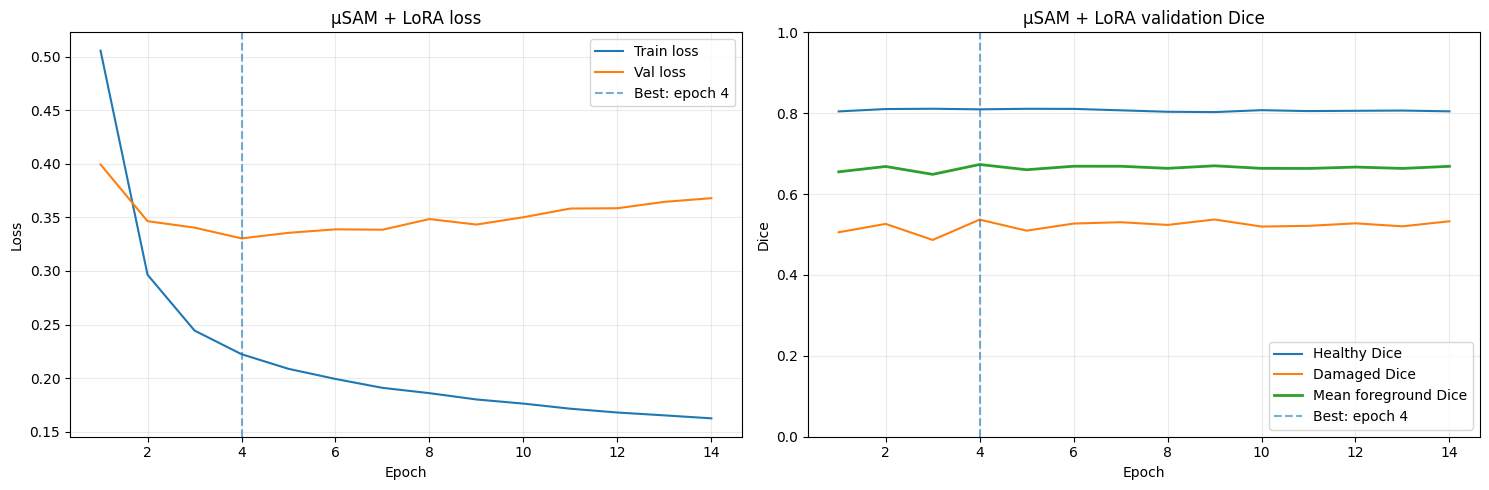

Best val loss: epoch 4, loss=0.3305
Best val Dice: epoch 4, mean=0.6732, healthy=0.8096, damaged=0.5368


In [11]:
# ================================
# Cell 9: Plot training history
# ================================
h=history

epochs=np.arange(1,len(h["train_loss"])+1)
best_dice_epoch=int(np.argmax(h["val_dice"]))+1
best_loss_epoch=int(np.argmin(h["val_loss"]))+1

fig,axs=plt.subplots(1,2,figsize=(15,5))

axs[0].plot(epochs,h["train_loss"],label="Train loss")
axs[0].plot(epochs,h["val_loss"],label="Val loss")
axs[0].axvline(best_loss_epoch,ls="--",alpha=.6,label=f"Best: epoch {best_loss_epoch}")
axs[0].set(xlabel="Epoch",ylabel="Loss",title="µSAM + LoRA loss")
axs[0].legend();axs[0].grid(alpha=.25)

axs[1].plot(epochs,h["val_dice_healthy"],label="Healthy Dice")
axs[1].plot(epochs,h["val_dice_damaged"],label="Damaged Dice")
axs[1].plot(epochs,h["val_dice"],label="Mean foreground Dice",linewidth=2)
axs[1].axvline(best_dice_epoch,ls="--",alpha=.6,label=f"Best: epoch {best_dice_epoch}")
axs[1].set(xlabel="Epoch",ylabel="Dice",title="µSAM + LoRA validation Dice",ylim=(0,1))
axs[1].legend();axs[1].grid(alpha=.25)

plt.tight_layout();plt.show()

print(f"Best val loss: epoch {best_loss_epoch}, loss={h['val_loss'][best_loss_epoch-1]:.4f}")
print(f"Best val Dice: epoch {best_dice_epoch}, mean={h['val_dice'][best_dice_epoch-1]:.4f}, "
      f"healthy={h['val_dice_healthy'][best_dice_epoch-1]:.4f}, "
      f"damaged={h['val_dice_damaged'][best_dice_epoch-1]:.4f}")

# Cell 10A — Evaluation on test set (Load best checkpoint + sliding-window / stitching helpers)

In [11]:
# ================================
# Cell 10: Evaluate best µSAM model on all test sets
# ================================
CKPT_PATH=BEST_DICE_CKPT_PATH
TEST_OVERLAP=128
TEST_STRIDE=PATCH_SIZE-TEST_OVERLAP
INFER_BATCH=8

# ---------- Build 3 global multiclass test sets ----------
TEST_CFG={"original":(2.0,7),"axondeep":(2.0,7),"new_montage":(2.0,7)}

def load_test(source):
    scale,gap=TEST_CFG[source]
    X,Y,_,names,shapes,missing=_load_source(source,"test",scale,gap,make_patches=False,require_both=source=="original")
    print(f"{source:12s} test: {len(X)} images | missing={len(missing)}")
    return {"images":X,"labels":Y,"names":names,"shapes":shapes,"scale":scale,"missing":missing}

TEST_SETS={source:load_test(source) for source in TEST_CFG}

# ---------- Load best µSAM checkpoint ----------
ckpt=torch.load(CKPT_PATH,map_location=DEVICE,weights_only=False)
sam.load_state_dict(ckpt["sam_state"])
ais_decoder.load_state_dict(ckpt["ais_state"])
sam.eval();ais_decoder.eval()

best_dice=ckpt.get("history",{}).get("best_dice",ckpt.get("monitor_value",np.nan))
print(f"\nLoaded: {CKPT_PATH}")
print(f"Epoch: {ckpt['epoch']} | best val Dice: {best_dice:.4f}")

# ---------- Sliding-window setup ----------
g1=cv2.getGaussianKernel(PATCH_SIZE,PATCH_SIZE/8)
GAUSS=(g1@g1.T).astype(np.float32)
GAUSS=np.maximum(GAUSS,GAUSS.max()*1e-3)

def positions(n):
    if n<=PATCH_SIZE:return [0]
    p=list(range(0,n-PATCH_SIZE+1,TEST_STRIDE))
    if p[-1]!=n-PATCH_SIZE:p.append(n-PATCH_SIZE)
    return p

@torch.inference_mode()
def predict_full(x):
    _,h,w=x.shape
    ph=max(PATCH_SIZE-h,0);pw=max(PATCH_SIZE-w,0)
    if ph or pw:x=np.pad(x,((0,0),(0,ph),(0,pw)),mode="reflect")
    _,H,W=x.shape
    coords=[(y,x0) for y in positions(H) for x0 in positions(W)]
    prob=np.zeros((NUM_CLASSES,H,W),np.float32);weight=np.zeros((H,W),np.float32)

    for k in range(0,len(coords),INFER_BATCH):
        bc=coords[k:k+INFER_BATCH]
        batch=np.stack([x[:,y:y+PATCH_SIZE,x0:x0+PATCH_SIZE] for y,x0 in bc])
        batch=torch.from_numpy(batch).float().to(DEVICE)
        batch=sam_normalize(batch)

        with torch.amp.autocast("cuda",enabled=DEVICE.type=="cuda"):
            out=torch.softmax(forward_logits(batch),1).float().cpu().numpy()

        for p,(y,x0) in zip(out,bc):
            prob[:,y:y+PATCH_SIZE,x0:x0+PATCH_SIZE]+=p*GAUSS
            weight[y:y+PATCH_SIZE,x0:x0+PATCH_SIZE]+=GAUSS

    return (prob/np.maximum(weight,1e-8))[...,:h,:w].argmax(0).astype(np.uint8)

def binary_dice(pred,gt,cls):
    p,g=pred==cls,gt==cls
    den=p.sum()+g.sum()
    return np.nan if den==0 else 2*(p&g).sum()/den

# ---------- Evaluate ----------
rows=[]

for source,ds in TEST_SETS.items():
    for x,y,name in tqdm(zip(ds["images"],ds["labels"],ds["names"]),total=len(ds["images"]),desc=f"Testing {source}"):
        pred=predict_full(x)
        hd=binary_dice(pred,y,1);dd=binary_dice(pred,y,2)
        hp,dp=int((y==1).sum()),int((y==2).sum())
        wd=(hd*hp+dd*dp)/(hp+dp) if hp+dp else np.nan

        rows.append({"dataset":source,"image":name,"healthy_dice":hd,"damaged_dice":dd,
                     "healthy_pixels":hp,"damaged_pixels":dp,"weighted_dice":wd})

test_df=pd.DataFrame(rows)

# ---------- Per-dataset summary ----------
summary=test_df.groupby("dataset").agg(
    n_images=("image","size"),
    healthy_dice=("healthy_dice","mean"),
    damaged_dice=("damaged_dice","mean"),
    healthy_pixels=("healthy_pixels","sum"),
    damaged_pixels=("damaged_pixels","sum")
)

summary["weighted_dice"]=(summary["healthy_dice"]*summary["healthy_pixels"]+
                          summary["damaged_dice"]*summary["damaged_pixels"])/(
                          summary["healthy_pixels"]+summary["damaged_pixels"])

for name,r in summary.iterrows():
    print(f"{name:12s} | n={int(r['n_images']):2d} | H={r['healthy_dice']:.4f} | "
          f"D={r['damaged_dice']:.4f} | Weighted={r['weighted_dice']:.4f}")

# ---------- All 3 test sets combined ----------
n_images=len(test_df)
h_mean=test_df["healthy_dice"].mean();d_mean=test_df["damaged_dice"].mean()
h_pixels=int(test_df["healthy_pixels"].sum());d_pixels=int(test_df["damaged_pixels"].sum())
overall_weighted=(h_mean*h_pixels+d_mean*d_pixels)/(h_pixels+d_pixels)

print(f"\nALL COMBINED | n={n_images:2d} | H={h_mean:.4f} | D={d_mean:.4f} | Weighted={overall_weighted:.4f}")

original     test: 18 images | missing=0


axondeep     test: 18 images | missing=0


new_montage  test: 1 images | missing=0

Loaded: C:\Users\Dhruba\Codes\micro_sam_lora\checkpoints\semantic_axondeep_ContactGap_upscale 2X_3.12X_usam_lora_AIS_img512\best_dice.pt
Epoch: 7 | best val Dice: 0.7400


Testing new_montage: 100%|███████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.74it/s]

axondeep     | n=18 | H=0.9253 | D=0.4355 | Weighted=0.9091
new_montage  | n= 1 | H=0.8683 | D=0.7267 | Weighted=0.8669
original     | n=18 | H=0.7553 | D=0.7950 | Weighted=0.7740

ALL COMBINED | n=37 | H=0.8411 | D=0.6233 | Weighted=0.8116


In [12]:
# ================================
# Cell 11: Noise removal + thin-bridge post-processing
# ================================
HEALTHY_MIN_AREA=100
DAMAGED_MIN_AREA=200
MIN_SPLIT_AREA=50
MIN_CORE_AREA=12
MIN_FINAL_AREA=20
MAX_EROSIONS=4
MAX_AREA_RATIO=4.
CUT_WIDTH=1
STRUCT=np.ones((3,3),bool)

def remove_small(mask,min_area):
    n,lab,stats,_=cv2.connectedComponentsWithStats(mask.astype(np.uint8),8)
    out=np.zeros_like(mask,dtype=np.uint8)
    for i in range(1,n):
        if stats[i,cv2.CC_STAT_AREA]>=min_area:out[lab==i]=1
    return out

def keep_largest(mask):
    lab,n=ndi.label(mask,structure=STRUCT)
    if not n:return np.zeros_like(mask,bool)
    sizes=ndi.sum(np.ones_like(mask),lab,range(1,n+1))
    return lab==(np.argmax(sizes)+1)

def split_thin_bridges(mask):
    mask=mask.astype(np.uint8)
    n,lab,stats,_=cv2.connectedComponentsWithStats(mask,8)
    out=np.zeros_like(mask);gap_all=np.zeros_like(mask,bool);splits=0
    pad=MAX_EROSIONS+CUT_WIDTH+2

    for cid in range(1,n):
        x,y,w,h,area=stats[cid]
        if area<MIN_SPLIT_AREA:out[lab==cid]=1;continue

        x0=max(0,x-pad);y0=max(0,y-pad);x1=min(mask.shape[1],x+w+pad);y1=min(mask.shape[0],y+h+pad)
        comp=lab[y0:y1,x0:x1]==cid;cores=None

        for it in range(1,MAX_EROSIONS+1):
            er=ndi.binary_erosion(comp,STRUCT,iterations=it)
            en,el,estats,_=cv2.connectedComponentsWithStats(er.astype(np.uint8),8)
            ids=[j for j in range(1,en) if estats[j,cv2.CC_STAT_AREA]>=MIN_CORE_AREA]
            if len(ids)==2:
                a1,a2=estats[ids[0],cv2.CC_STAT_AREA],estats[ids[1],cv2.CC_STAT_AREA]
                if max(a1,a2)/max(min(a1,a2),1)<=MAX_AREA_RATIO:cores=[el==ids[0],el==ids[1]];break

        roi=out[y0:y1,x0:x1]
        if cores is None:roi[comp]=1;continue

        d1=ndi.distance_transform_edt(~cores[0]);d2=ndi.distance_transform_edt(~cores[1])
        p1=comp&(d1<=d2);p2=comp&(d2<d1)

        if min(p1.sum(),p2.sum())<MIN_FINAL_AREA or max(p1.sum(),p2.sum())/max(min(p1.sum(),p2.sum()),1)>MAX_AREA_RATIO:
            roi[comp]=1;continue

        cut=(p1&ndi.binary_dilation(p2,STRUCT))|(p2&ndi.binary_dilation(p1,STRUCT))
        if CUT_WIDTH>1:cut=ndi.binary_dilation(cut,STRUCT,iterations=CUT_WIDTH-1)&comp
        p1=keep_largest(p1&~cut);p2=keep_largest(p2&~cut)

        if min(p1.sum(),p2.sum())<MIN_FINAL_AREA or max(p1.sum(),p2.sum())/max(min(p1.sum(),p2.sum()),1)>MAX_AREA_RATIO:
            roi[comp]=1;continue

        roi[p1|p2]=1;gap_all[y0:y1,x0:x1]|=cut;splits+=1

    return out,gap_all,splits

def postprocess_semantic(pred):
    h=remove_small(pred==1,HEALTHY_MIN_AREA);d=remove_small(pred==2,DAMAGED_MIN_AREA)
    h,hgap,hs=split_thin_bridges(h);d,dgap,ds=split_thin_bridges(d)
    out=np.zeros_like(pred,np.uint8);out[h>0]=1;out[d>0]=2
    return out,hgap|dgap,hs,ds

POST_TEST_SETS={}
rows=[]

for source,ds in TEST_SETS.items():
    preds_raw,preds_post=[],[]

    for x,y,name in tqdm(zip(ds["images"],ds["labels"],ds["names"]),total=len(ds["images"]),desc=f"Post-process {source}"):
        raw=predict_full(x)
        post,gap,hs,dsplits=postprocess_semantic(raw)

        hd=binary_dice(post,y,1);dd=binary_dice(post,y,2)
        hp,dp=int((y==1).sum()),int((y==2).sum())
        wd=(hd*hp+dd*dp)/(hp+dp) if hp+dp else np.nan

        rows.append({"dataset":source,"image":name,"healthy_dice":hd,"damaged_dice":dd,
                     "healthy_pixels":hp,"damaged_pixels":dp,"weighted_dice":wd,
                     "healthy_splits":hs,"damaged_splits":dsplits,"removed_gap_pixels":int(gap.sum())})

        preds_raw.append(raw);preds_post.append(post)

    POST_TEST_SETS[source]={"raw":preds_raw,"post":preds_post}

post_df=pd.DataFrame(rows)

summary=post_df.groupby("dataset").agg(
    n_images=("image","size"),
    healthy_dice=("healthy_dice","mean"),
    damaged_dice=("damaged_dice","mean"),
    healthy_pixels=("healthy_pixels","sum"),
    damaged_pixels=("damaged_pixels","sum"),
    healthy_splits=("healthy_splits","sum"),
    damaged_splits=("damaged_splits","sum"),
    removed_gap_pixels=("removed_gap_pixels","sum")
)

summary["weighted_dice"]=(summary["healthy_dice"]*summary["healthy_pixels"]+
                          summary["damaged_dice"]*summary["damaged_pixels"])/(
                          summary["healthy_pixels"]+summary["damaged_pixels"])

display(summary.round(4))

# ---------- All 3 test sets combined ----------
n_images=len(post_df)
h_mean=post_df["healthy_dice"].mean();d_mean=post_df["damaged_dice"].mean()
h_pixels=int(post_df["healthy_pixels"].sum());d_pixels=int(post_df["damaged_pixels"].sum())
h_splits=int(post_df["healthy_splits"].sum());d_splits=int(post_df["damaged_splits"].sum())
gap_pixels=int(post_df["removed_gap_pixels"].sum())

overall_weighted=(h_mean*h_pixels+d_mean*d_pixels)/(h_pixels+d_pixels)

print(f"\nALL COMBINED | n={n_images} | H={h_mean:.4f} | D={d_mean:.4f} | Weighted={overall_weighted:.4f} | "
      f"H pixels={h_pixels:,} | D pixels={d_pixels:,} | H splits={h_splits} | D splits={d_splits} | "
      f"Gap pixels={gap_pixels:,}")

Post-process new_montage: 100%|██████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.99s/it]


,n_images,healthy_dice,damaged_dice,healthy_pixels,damaged_pixels,healthy_splits,damaged_splits,removed_gap_pixels,weighted_dice
dataset,,,,,,,,,
axondeep,18,0.9253,0.4325,31689376,1084648,42,1,726,0.9090
new_montage,1,0.8674,0.7267,664232,7000,7,0,113,0.8660
original,18,0.7553,0.7953,5420024,4822408,14,8,464,0.7741



ALL COMBINED | n=37 | H=0.8410 | D=0.6221 | Weighted=0.8114 | H pixels=37,773,632 | D pixels=5,914,056 | H splits=63 | D splits=9 | Gap pixels=1,303


In [13]:
# ================================
# Cell 12: Axon count + instance matching
# ================================
COVERAGE_THR=.33

def label_instances(mask):
    n,lab=cv2.connectedComponents(mask.astype(np.uint8),8)
    return lab,n-1

def match_instances(gt_mask,pred_mask,thr=COVERAGE_THR):
    gt,ng=label_instances(gt_mask);pr,npred=label_instances(pred_mask)
    if ng==0:return {"gt":0,"pred":npred,"tp":0,"fp":npred,"fn":0}
    if npred==0:return {"gt":ng,"pred":0,"tp":0,"fp":0,"fn":ng}

    gt_area=np.bincount(gt.ravel(),minlength=ng+1)[1:];pairs=[]
    overlap=(gt>0)&(pr>0)

    if overlap.any():
        ids=np.stack([gt[overlap],pr[overlap]],1);unique,count=np.unique(ids,axis=0,return_counts=True)
        for (g,p),inter in zip(unique,count):
            coverage=inter/gt_area[g-1]
            if coverage>=thr:pairs.append((coverage,int(inter),int(g),int(p)))

    pairs.sort(reverse=True);used_g,used_p=set(),set()
    for coverage,inter,g,p in pairs:
        if g not in used_g and p not in used_p:used_g.add(g);used_p.add(p)

    tp=len(used_g)
    return {"gt":ng,"pred":npred,"tp":tp,"fp":npred-tp,"fn":ng-tp}

rows=[]

for source,ds in TEST_SETS.items():
    posts=POST_TEST_SETS[source]["post"]
    for y,pred,name in tqdm(zip(ds["labels"],posts,ds["names"]),total=len(posts),desc=f"Counting {source}"):
        for cls,label in [(1,"healthy"),(2,"damaged")]:
            m=match_instances(y==cls,pred==cls)
            rows.append({"dataset":source,"image":name,"class":label,**m})

count_df=pd.DataFrame(rows)

count_summary=count_df.groupby(["dataset","class"])[["gt","pred","tp","fp","fn"]].sum()
count_summary["precision"]=count_summary["tp"]/(count_summary["tp"]+count_summary["fp"]).replace(0,np.nan)
count_summary["recall"]=count_summary["tp"]/(count_summary["tp"]+count_summary["fn"]).replace(0,np.nan)
count_summary["f1"]=2*count_summary["precision"]*count_summary["recall"]/(count_summary["precision"]+count_summary["recall"])
count_summary["tp_pred_%"]=100*count_summary["tp"]/count_summary["pred"].replace(0,np.nan)
count_summary["fp_pred_%"]=100*count_summary["fp"]/count_summary["pred"].replace(0,np.nan)

display(count_summary.round(4))

print(f"\nMatching criterion: intersection / GT area >= {COVERAGE_THR:.0%}")

for (dataset,cls),r in count_summary.iterrows():
    print(f"{dataset:12s} | {cls:7s} | GT={int(r['gt']):4d} | Pred={int(r['pred']):4d} | "
          f"TP={int(r['tp']):4d} ({r['tp_pred_%']:.1f}%) | "
          f"FP={int(r['fp']):4d} ({r['fp_pred_%']:.1f}%) | "
          f"FN={int(r['fn']):4d} | P={r['precision']:.3f} | R={r['recall']:.3f} | F1={r['f1']:.3f}")

# ---------- All 3 test sets combined ----------
combined=count_df.groupby("class")[["gt","pred","tp","fp","fn"]].sum()
combined["precision"]=combined["tp"]/(combined["tp"]+combined["fp"]).replace(0,np.nan)
combined["recall"]=combined["tp"]/(combined["tp"]+combined["fn"]).replace(0,np.nan)
combined["f1"]=2*combined["precision"]*combined["recall"]/(combined["precision"]+combined["recall"])
combined["tp_pred_%"]=100*combined["tp"]/combined["pred"].replace(0,np.nan)
combined["fp_pred_%"]=100*combined["fp"]/combined["pred"].replace(0,np.nan)

print("\nALL 3 TEST SETS COMBINED")

for cls,r in combined.iterrows():
    print(f"{cls:7s} | GT={int(r['gt']):5d} | Pred={int(r['pred']):5d} | "
          f"TP={int(r['tp']):5d} ({r['tp_pred_%']:.1f}%) | "
          f"FP={int(r['fp']):5d} ({r['fp_pred_%']:.1f}%) | "
          f"FN={int(r['fn']):5d} | P={r['precision']:.3f} | "
          f"R={r['recall']:.3f} | F1={r['f1']:.3f}")

# ---------- Healthy + Damaged total ----------
t=combined[["gt","pred","tp","fp","fn"]].sum()
p=t["tp"]/(t["tp"]+t["fp"])
r=t["tp"]/(t["tp"]+t["fn"])
f1=2*p*r/(p+r)
tp_pct=100*t["tp"]/t["pred"]
fp_pct=100*t["fp"]/t["pred"]

print(f"{'total':7s} | GT={int(t['gt']):5d} | Pred={int(t['pred']):5d} | "
      f"TP={int(t['tp']):5d} ({tp_pct:.1f}%) | "
      f"FP={int(t['fp']):5d} ({fp_pct:.1f}%) | "
      f"FN={int(t['fn']):5d} | P={p:.3f} | R={r:.3f} | F1={f1:.3f}")

Counting new_montage: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.04it/s]


gt  pred    tp   fp   fn  precision  recall      f1  \
dataset     class                                                            
axondeep    damaged   129   111    64   47   65     0.5766  0.4961  0.5333   
            healthy  6230  5873  5433  440  797     0.9251  0.8721  0.8978   
new_montage damaged     5     1     1    0    4     1.0000  0.2000  0.3333   
            healthy   715   613   558   55  157     0.9103  0.7804  0.8404   
original    damaged   519   697   434  263   85     0.6227  0.8362  0.7138   
            healthy  3743  3817  2911  906  832     0.7626  0.7777  0.7701   

                     tp_pred_%  fp_pred_%  
dataset     class                          
axondeep    damaged    57.6577    42.3423  
            healthy    92.5081     7.4919  
new_montage damaged   100.0000     0.0000  
            healthy    91.0277     8.9723  
original    damaged    62.2669    37.7331  
            healthy    76.2641    23.7359


Matching criterion: intersection / GT area >= 33%
axondeep     | damaged | GT= 129 | Pred= 111 | TP=  64 (57.7%) | FP=  47 (42.3%) | FN=  65 | P=0.577 | R=0.496 | F1=0.533
axondeep     | healthy | GT=6230 | Pred=5873 | TP=5433 (92.5%) | FP= 440 (7.5%) | FN= 797 | P=0.925 | R=0.872 | F1=0.898
new_montage  | damaged | GT=   5 | Pred=   1 | TP=   1 (100.0%) | FP=   0 (0.0%) | FN=   4 | P=1.000 | R=0.200 | F1=0.333
new_montage  | healthy | GT= 715 | Pred= 613 | TP= 558 (91.0%) | FP=  55 (9.0%) | FN= 157 | P=0.910 | R=0.780 | F1=0.840
original     | damaged | GT= 519 | Pred= 697 | TP= 434 (62.3%) | FP= 263 (37.7%) | FN=  85 | P=0.623 | R=0.836 | F1=0.714
original     | healthy | GT=3743 | Pred=3817 | TP=2911 (76.3%) | FP= 906 (23.7%) | FN= 832 | P=0.763 | R=0.778 | F1=0.770

ALL 3 TEST SETS COMBINED
damaged | GT=  653 | Pred=  809 | TP=  499 (61.7%) | FP=  310 (38.3%) | FN=  154 | P=0.617 | R=0.764 | F1=0.683
healthy | GT=10688 | Pred=10303 | TP= 8902 (86.4%) | FP= 1401 (13.6%) | FN= 1786 

In [14]:
# ================================
# Cell 12.5: Count agreement — Abs. % difference + Pearson R
# Healthy, Damaged, and Total Axons
# ================================
from scipy.stats import pearsonr

rows=[]

def add_agreement(dataset,cls,sub):
    valid=sub["gt"]>0
    abs_pct=(100*(sub.loc[valid,"pred"]-sub.loc[valid,"gt"]).abs()/sub.loc[valid,"gt"]).mean()

    if len(sub)>=2 and sub["gt"].nunique()>1 and sub["pred"].nunique()>1:
        r,_=pearsonr(sub["gt"],sub["pred"])
    else:r=np.nan

    rows.append({"dataset":dataset,"class":cls,"n_images":len(sub),
                 "gt_total":int(sub["gt"].sum()),"pred_total":int(sub["pred"].sum()),
                 "abs_pct_diff":abs_pct,"pearson_r":r})

# ---------- Healthy / Damaged: individual test sets ----------
for (dataset,cls),sub in count_df.groupby(["dataset","class"]):
    add_agreement(dataset,cls,sub)

# ---------- Healthy / Damaged: all 3 test sets combined ----------
for cls,sub in count_df.groupby("class"):
    add_agreement("combined",cls,sub)

# ---------- Healthy + Damaged TOTAL per image ----------
# Keep all non-class columns identifying each image
id_cols=[c for c in count_df.columns if c not in ["class","gt","pred"]]

# We only need dataset + image identifier for aggregation
image_col=[c for c in id_cols if c!="dataset"][0]

total_df=(count_df.groupby(["dataset",image_col],as_index=False)
          .agg(gt=("gt","sum"),pred=("pred","sum")))

# Total axons: individual test sets
for dataset,sub in total_df.groupby("dataset"):
    add_agreement(dataset,"total",sub)

# Total axons: all 37 images combined
add_agreement("combined","total",total_df)

agreement_df=pd.DataFrame(rows)
display(agreement_df.round(4))

for _,r in agreement_df.iterrows():
    print(f"{r['dataset']:12s} | {r['class']:7s} | n={int(r['n_images']):2d} | "
          f"GT={int(r['gt_total']):5d} | Pred={int(r['pred_total']):5d} | "
          f"Abs % diff={r['abs_pct_diff']:.2f}% | Pearson R={r['pearson_r']:.3f}")

,dataset,class,n_images,gt_total,pred_total,abs_pct_diff,pearson_r
0,axondeep,damaged,18,129,111,35.1824,0.9821
1,axondeep,healthy,18,6230,5873,5.7710,0.9672
2,new_montage,damaged,1,5,1,80.0000,NaN
3,new_montage,healthy,1,715,613,14.2657,NaN
4,original,damaged,18,519,697,38.5744,0.6575
5,original,healthy,18,3743,3817,20.7047,0.9031
6,combined,damaged,37,653,809,38.3907,0.9293
7,combined,healthy,37,10688,10303,13.2656,0.9698
8,axondeep,total,18,6359,5984,5.9467,0.9640
9,new_montage,total,1,720,614,14.7222,NaN


axondeep     | damaged | n=18 | GT=  129 | Pred=  111 | Abs % diff=35.18% | Pearson R=0.982
axondeep     | healthy | n=18 | GT= 6230 | Pred= 5873 | Abs % diff=5.77% | Pearson R=0.967
new_montage  | damaged | n= 1 | GT=    5 | Pred=    1 | Abs % diff=80.00% | Pearson R=nan
new_montage  | healthy | n= 1 | GT=  715 | Pred=  613 | Abs % diff=14.27% | Pearson R=nan
original     | damaged | n=18 | GT=  519 | Pred=  697 | Abs % diff=38.57% | Pearson R=0.658
original     | healthy | n=18 | GT= 3743 | Pred= 3817 | Abs % diff=20.70% | Pearson R=0.903
combined     | damaged | n=37 | GT=  653 | Pred=  809 | Abs % diff=38.39% | Pearson R=0.929
combined     | healthy | n=37 | GT=10688 | Pred=10303 | Abs % diff=13.27% | Pearson R=0.970
axondeep     | total   | n=18 | GT= 6359 | Pred= 5984 | Abs % diff=5.95% | Pearson R=0.964
new_montage  | total   | n= 1 | GT=  720 | Pred=  614 | Abs % diff=14.72% | Pearson R=nan
original     | total   | n=18 | GT= 4262 | Pred= 4514 | Abs % diff=17.53% | Pearson R=0.

In [18]:
# ================================
# Cell 13: µSAM post-processed GT vs prediction
# ================================
SOURCE="axondeep"   # "original", "axondeep", "new_montage"

ds=TEST_SETS[SOURCE]
posts=POST_TEST_SETS[SOURCE]["post"]
ALPHA=.45
COLORS=np.array([[0,0,0],[0,255,0],[255,0,0]],np.uint8)

SAVE_DIR=OVERLAY_DIR/"axondeep"
SAVE_DIR.mkdir(parents=True,exist_ok=True)

for i,(x,y,pred,name) in enumerate(tqdm(zip(ds["images"],ds["labels"],posts,ds["names"]),
                                           total=len(posts),desc=f"Plotting {SOURCE} post")):
    img=np.clip(x.transpose(1,2,0),0,1)
    gt_color,pr_color=COLORS[y]/255.,COLORS[pred]/255.
    gt_overlay,pr_overlay=img.copy(),img.copy()
    gm,pm=y>0,pred>0
    gt_overlay[gm]=(1-ALPHA)*img[gm]+ALPHA*gt_color[gm]
    pr_overlay[pm]=(1-ALPHA)*img[pm]+ALPHA*pr_color[pm]

    hd,dd=binary_dice(pred,y,1),binary_dice(pred,y,2)
    hp,dp=(y==1).sum(),(y==2).sum()
    wd=(hd*hp+dd*dp)/(hp+dp) if hp+dp else np.nan

    hm=match_instances(y==1,pred==1)
    dm=match_instances(y==2,pred==2)
    htp=100*hm["tp"]/hm["pred"] if hm["pred"] else 0
    dtp=100*dm["tp"]/dm["pred"] if dm["pred"] else 0

    # One figure per case
    fig,axs=plt.subplots(1,3,figsize=(15,5))

    axs[0].imshow(img)
    axs[0].set_title(f"{name}\nOriginal")

    axs[1].imshow(gt_overlay)
    axs[1].set_title("Ground truth")

    axs[2].imshow(pr_overlay)
    axs[2].set_title(
        f"H Dice={hd:.3f}, TP={hm['tp']}/{hm['pred']} ({htp:.1f}%) | "
        f"D Dice={dd:.3f}, TP={dm['tp']}/{dm['pred']} ({dtp:.1f}%)\n"
        f"Weighted Dice={wd:.3f}"
    )

    for ax in axs:ax.axis("off")
    plt.tight_layout()

    # Save each case separately
    safe_name=Path(str(name)).stem
    save_path=SAVE_DIR/f"{safe_name}.tiff"
    fig.savefig(save_path,dpi=300,bbox_inches="tight",format="tiff")
    plt.close(fig)

print(f"Saved {len(posts)} TIFF files to:\n{SAVE_DIR}")

Plotting axondeep post: 100%|██████████████████████████████████████████████████████████| 18/18 [01:18<00:00,  4.37s/it]

Saved 18 TIFF files to:
C:\Users\Dhruba\Codes\micro_sam_lora\checkpoints\saved overlay images for full training


In [21]:
# ================================
# Cell 14: New montage post-processed GT vs prediction
# ================================
ds=TEST_SETS["new_montage"]
posts=POST_TEST_SETS["new_montage"]["post"]
ALPHA=.45
COLORS=np.array([[0,0,0],[0,255,0],[255,0,0]],np.uint8)

SAVE_DIR=OVERLAY_DIR/"new_montage"
SAVE_DIR.mkdir(parents=True,exist_ok=True)

for i,(x,y,pred,name) in enumerate(tqdm(zip(ds["images"],ds["labels"],posts,ds["names"]),
                                           total=len(posts),desc="Plotting new montage post")):
    img=np.clip(x.transpose(1,2,0),0,1)
    gt_color,pr_color=COLORS[y]/255.,COLORS[pred]/255.
    gt_overlay,pr_overlay=img.copy(),img.copy()
    gm,pm=y>0,pred>0
    gt_overlay[gm]=(1-ALPHA)*img[gm]+ALPHA*gt_color[gm]
    pr_overlay[pm]=(1-ALPHA)*img[pm]+ALPHA*pr_color[pm]

    hd,dd=binary_dice(pred,y,1),binary_dice(pred,y,2)
    hp,dp=(y==1).sum(),(y==2).sum()
    wd=(hd*hp+dd*dp)/(hp+dp) if hp+dp else np.nan

    hm=match_instances(y==1,pred==1)
    dm=match_instances(y==2,pred==2)
    htp=100*hm["tp"]/hm["pred"] if hm["pred"] else 0
    dtp=100*dm["tp"]/dm["pred"] if dm["pred"] else 0

    # One figure per case
    fig,axs=plt.subplots(1,3,figsize=(15,5))

    axs[0].imshow(img)
    axs[0].set_title(f"{name}\nOriginal")

    axs[1].imshow(gt_overlay)
    axs[1].set_title("Ground truth")

    axs[2].imshow(pr_overlay)
    axs[2].set_title(
        f"H Dice={hd:.3f}, TP={hm['tp']}/{hm['pred']} ({htp:.1f}%) | "
        f"D Dice={dd:.3f}, TP={dm['tp']}/{dm['pred']} ({dtp:.1f}%)\n"
        f"Weighted Dice={wd:.3f}"
    )

    for ax in axs:ax.axis("off")
    plt.tight_layout()

    # Save each case using its original name
    safe_name=Path(str(name)).stem
    save_path=SAVE_DIR/f"{safe_name}.tiff"
    fig.savefig(save_path,dpi=300,bbox_inches="tight",format="tiff")
    plt.close(fig)

print(f"Saved {len(posts)} TIFF files to:\n{SAVE_DIR}")

Plotting new montage post: 100%|█████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.67s/it]

Saved 1 TIFF files to:
C:\Users\Dhruba\Codes\micro_sam_lora\checkpoints\saved overlay images for full training


In [ ]:
# ================================
# Cell 15: Original post-processed GT vs prediction
# ================================
ds=TEST_SETS["original"]
posts=POST_TEST_SETS["original"]["post"]
ALPHA=.45
COLORS=np.array([[0,0,0],[0,255,0],[255,0,0]],np.uint8)

SAVE_DIR=OVERLAY_DIR/"original"
SAVE_DIR.mkdir(parents=True,exist_ok=True)

for i,(x,y,pred,name) in enumerate(tqdm(zip(ds["images"],ds["labels"],posts,ds["names"]),
                                           total=len(posts),desc="Plotting original post")):
    img=np.clip(x.transpose(1,2,0),0,1)
    gt_color,pr_color=COLORS[y]/255.,COLORS[pred]/255.
    gt_overlay,pr_overlay=img.copy(),img.copy()
    gm,pm=y>0,pred>0
    gt_overlay[gm]=(1-ALPHA)*img[gm]+ALPHA*gt_color[gm]
    pr_overlay[pm]=(1-ALPHA)*img[pm]+ALPHA*pr_color[pm]

    hd,dd=binary_dice(pred,y,1),binary_dice(pred,y,2)
    hp,dp=(y==1).sum(),(y==2).sum()
    wd=(hd*hp+dd*dp)/(hp+dp) if hp+dp else np.nan

    hm=match_instances(y==1,pred==1)
    dm=match_instances(y==2,pred==2)
    htp=100*hm["tp"]/hm["pred"] if hm["pred"] else 0
    dtp=100*dm["tp"]/dm["pred"] if dm["pred"] else 0

    # One figure per case
    fig,axs=plt.subplots(1,3,figsize=(15,5))

    axs[0].imshow(img)
    axs[0].set_title(f"{name}\nOriginal")

    axs[1].imshow(gt_overlay)
    axs[1].set_title("Ground truth")

    axs[2].imshow(pr_overlay)
    axs[2].set_title(
        f"H Dice={hd:.3f}, TP={hm['tp']}/{hm['pred']} ({htp:.1f}%) | "
        f"D Dice={dd:.3f}, TP={dm['tp']}/{dm['pred']} ({dtp:.1f}%)\n"
        f"Weighted Dice={wd:.3f}"
    )

    for ax in axs:ax.axis("off")
    plt.tight_layout()

    # Save each case separately using original filename
    safe_name=Path(str(name)).stem
    save_path=SAVE_DIR/f"{safe_name}.tiff"
    fig.savefig(save_path,dpi=300,bbox_inches="tight",format="tiff")
    plt.close(fig)

print(f"Saved {len(posts)} TIFF files to:\n{SAVE_DIR}")

Plotting original post:  94%|██████████████████████████████████████████████████████▊   | 17/18 [00:38<00:02,  2.39s/it]